In [ ]:
import numpy as np
import pandas as pd
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
from datetime import datetime
warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)
torch.manual_seed(42)



In [ ]:
# Create directory for saving results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
results_dir = f"results_{timestamp}"
os.makedirs(results_dir, exist_ok=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [ ]:
# Load features and labels
visual_features = np.load("/kaggle/input/final-cmu-pro/visual_features.npy")  # Shape: (2199, 128)
audio_features = np.load("/kaggle/input/final-cmu-pro/audio_features.npy")    # Shape: (2199, 74)
labels_df = pd.read_csv("/kaggle/input/final-cmu-pro/labels.csv")             # Shape: (2199, 11)



In [ ]:
def min_max_scale(features, range_min=0, range_max=1):
    feat_min = np.min(features, axis=0)
    feat_max = np.max(features, axis=0)
    scaled = (features - feat_min) / (feat_max - feat_min + 1e-8)  # Avoid division by zero
    scaled = scaled * (range_max - range_min) + range_min  # Rescale to desired range
    return scaled

audio_features = min_max_scale(audio_features, -1, 1)
visual_features = min_max_scale(visual_features)



In [ ]:
# Split data into train/test/valid
def split_data(mode):
    idx = labels_df[labels_df["mode"] == mode].index
    return {
        "text": labels_df.loc[idx, "text"].values,
        "visual": visual_features[idx],
        "audio": audio_features[idx],
        "label": labels_df.loc[idx, "label"].values,  # Regression (-3 to +3)
    }

train_data = split_data("train")
test_data = split_data("test")
valid_data = split_data("valid")



In [ ]:
# BERT Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

class MultimodalDataset(Dataset):
    def __init__(self, data):
        self.text = data["text"]
        self.visual = torch.FloatTensor(data["visual"])
        self.audio = torch.FloatTensor(data["audio"])
        self.label = torch.FloatTensor(data["label"])

    def __len__(self):
        return len(self.text)

    def __getitem__(self, idx):
        text_encoded = tokenizer(
            self.text[idx],
            padding="max_length",
            truncation=True,
            max_length=50,
            return_tensors="pt"
        )
        return {
            "input_ids": text_encoded["input_ids"].squeeze(0),
            "attention_mask": text_encoded["attention_mask"].squeeze(0),
            "visual": self.visual[idx],
            "audio": self.audio[idx],
            "label": self.label[idx],
        }

# Create dataloaders
batch_size = 32
train_loader = DataLoader(MultimodalDataset(train_data), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(MultimodalDataset(test_data), batch_size=batch_size)
valid_loader = DataLoader(MultimodalDataset(valid_data), batch_size=batch_size)



In [ ]:
class TCT(nn.Module):
    def __init__(self, text_dim=768, audio_dim=74, visual_dim=128, num_heads=2):
        super().__init__()
        self.text_dim = text_dim
        self.audio_proj = nn.Linear(audio_dim, text_dim)
        self.visual_proj = nn.Linear(visual_dim, text_dim)

        self.multihead_attn = nn.MultiheadAttention(text_dim, num_heads)
        self.layer_norm = nn.LayerNorm(text_dim)
        self.ffn = nn.Sequential(
            nn.Linear(text_dim, 4 * text_dim),
            nn.ReLU(),
            nn.Linear(4 * text_dim, text_dim)
        )

    def forward(self, text, audio, visual):
        # Project audio and visual to text dimension
        audio_proj = self.audio_proj(audio).unsqueeze(1)  # [batch, 1, 768]
        visual_proj = self.visual_proj(visual).unsqueeze(1)  # [batch, 1, 768]

        # Compute attention scores
        T_a = torch.matmul(text, audio_proj.transpose(1, 2))
        T_v = torch.matmul(text, visual_proj.transpose(1, 2))
        T_av = (T_a + T_v) / 2

        # Multi-head attention
        Q = text.transpose(0, 1)
        K = V = (audio_proj + visual_proj).transpose(0, 1)
        attn_output, _ = self.multihead_attn(Q, K, V)
        output = self.layer_norm(text + attn_output.transpose(0, 1))
        output = self.layer_norm(output + self.ffn(output))
        return output



In [ ]:
class TF_BERT(nn.Module):
    """TF-BERT Model - Modified for Regression Only"""
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.tct = TCT(text_dim=768, audio_dim=74, visual_dim=128)
        self.regressor = nn.Linear(768, 1)   # For regression (-3 to +3)

    def forward(self, input_ids, attention_mask, visual, audio):
        # BERT text encoding
        text_output = self.bert(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state

        # TCT fusion
        fused_output = self.tct(text_output, audio, visual)

        # Pooling for sentence-level representation
        pooled_output = fused_output.mean(dim=1)

        # Regression output
        score = self.regressor(pooled_output).squeeze(-1)
        return score

model = TF_BERT().to(device)



In [ ]:
# Only use regression loss
criterion_reg = nn.L1Loss()  # MAE loss for regression
optimizer = optim.Adam(model.parameters(), lr=1e-5)

def train_epoch(model, dataloader):
    model.train()
    total_loss = 0
    progress_bar = tqdm(dataloader, desc="Training")
    for batch in progress_bar:
        optimizer.zero_grad()
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        visual = batch["visual"].to(device)
        audio = batch["audio"].to(device)
        label = batch["label"].to(device)

        score = model(input_ids, attention_mask, visual, audio)
        loss = criterion_reg(score, label)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        progress_bar.set_postfix({"loss": loss.item()})
    return total_loss / len(dataloader)



In [ ]:
def evaluate(model, dataloader):
    model.eval()
    scores, truths = [], []
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluation"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            visual = batch["visual"].to(device)
            audio = batch["audio"].to(device)
            label = batch["label"].to(device)

            score = model(input_ids, attention_mask, visual, audio)
            loss = criterion_reg(score, label)
            total_loss += loss.item()

            scores.extend(score.cpu().numpy())
            truths.extend(label.cpu().numpy())
    return np.array(scores), np.array(truths), total_loss / len(dataloader)



In [ ]:
def compute_regression_metrics(scores, truths):
    # Regression metrics (MAE, Pearson)
    mae = mean_absolute_error(truths, scores)
    pearson = pearsonr(truths, scores)[0]

    return {
        "MAE": mae,
        "Pearson": pearson
    }

def plot_loss_curves(train_losses, valid_losses, test_loss=None, save_path=None):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(valid_losses, label="Validation Loss")
    if test_loss is not None:
        plt.axhline(y=test_loss, color='r', linestyle='--', label="Test Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss (MAE)")
    plt.title("Training and Validation Loss Curves")
    plt.legend()
    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close()

def plot_regression_scatter(truths, scores, title="Regression Predictions", save_path=None):
    plt.figure(figsize=(10, 6))
    plt.scatter(truths, scores, alpha=0.5)

    # Add ideal prediction line
    min_val = min(min(truths), min(scores))
    max_val = max(max(truths), max(scores))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--')

    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.title(title)

    # Add metrics to plot
    metrics = compute_regression_metrics(scores, truths)
    plt.text(min_val, max_val, f"MAE: {metrics['MAE']:.4f}\nPearson: {metrics['Pearson']:.4f}",
             bbox=dict(facecolor='white', alpha=0.8))

    if save_path:
        plt.savefig(save_path)
    plt.show()
    plt.close()



In [ ]:
# Training loop with early stopping
train_losses = []
valid_losses = []
best_valid_loss = float('inf')
patience = 5
no_improvement = 0

# Track metrics for each epoch
validation_metrics_history = []

max_epochs = 50
for epoch in range(max_epochs):
    # Training
    epoch_train_loss = train_epoch(model, train_loader)
    train_losses.append(epoch_train_loss)

    # Validation
    scores, truths, epoch_valid_loss = evaluate(model, valid_loader)
    valid_losses.append(epoch_valid_loss)
    metrics = compute_regression_metrics(scores, truths)
    validation_metrics_history.append(metrics)

    print(f"Epoch {epoch+1}/{max_epochs}")
    print(f"Train Loss: {epoch_train_loss:.4f}, Valid Loss: {epoch_valid_loss:.4f}")
    print(f"Validation Metrics: MAE: {metrics['MAE']:.4f}, Pearson: {metrics['Pearson']:.4f}")

    # Early stopping check
    if epoch_valid_loss < best_valid_loss:
        best_valid_loss = epoch_valid_loss
        no_improvement = 0
        # Save best model
        torch.save(model.state_dict(), os.path.join(results_dir, "best_model.pt"))
    else:
        no_improvement += 1
        if no_improvement >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break



Evaluation: 100%|██████████| 8/8 [00:00<00:00, 18.34it/s]


Epoch 1/50
Train Loss: 1.1450, Valid Loss: 1.1389
Validation Metrics: MAE: 1.1063, Pearson: 0.5618


Evaluation: 100%|██████████| 8/8 [00:00<00:00, 18.29it/s]


Epoch 2/50
Train Loss: 0.8228, Valid Loss: 0.8619
Validation Metrics: MAE: 0.8907, Pearson: 0.7205


Evaluation: 100%|██████████| 8/8 [00:00<00:00, 18.38it/s]


...

Epoch 10/50
Train Loss: 0.2732, Valid Loss: 0.7528
Validation Metrics: MAE: 0.7939, Pearson: 0.7651


Evaluation: 100%|██████████| 8/8 [00:00<00:00, 18.36it/s]


Epoch 11/50
Train Loss: 0.2737, Valid Loss: 0.7654
Validation Metrics: MAE: 0.7933, Pearson: 0.7715


Evaluation: 100%|██████████| 8/8 [00:00<00:00, 18.37it/s]

Epoch 12/50
Train Loss: 0.2460, Valid Loss: 0.7570
Validation Metrics: MAE: 0.7923, Pearson: 0.7682
Early stopping triggered after 12 epochs!


Evaluation: 100%|██████████| 22/22 [00:01<00:00, 16.69it/s]


Test Metrics: MAE: 0.8044, Pearson: 0.7524


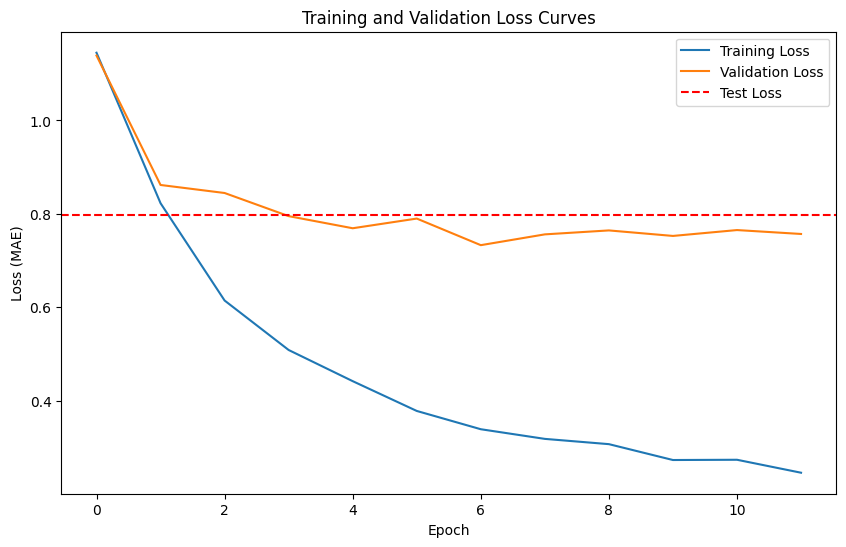

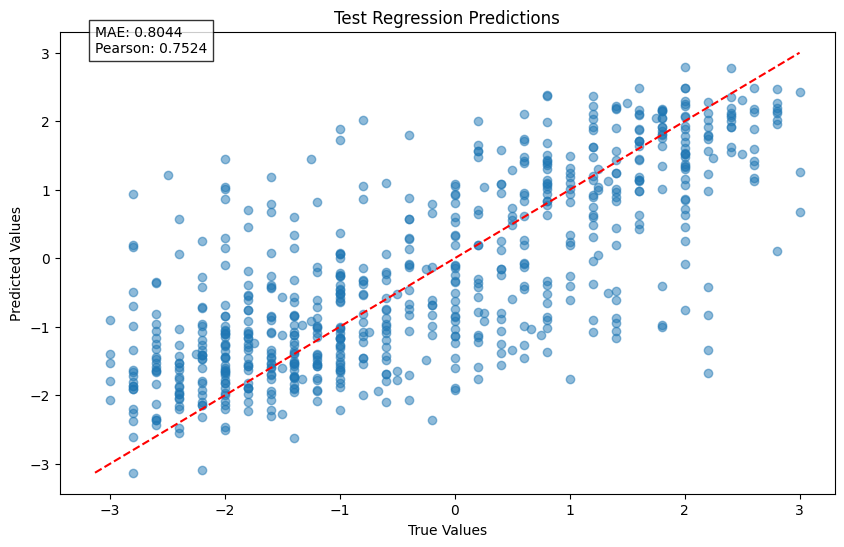

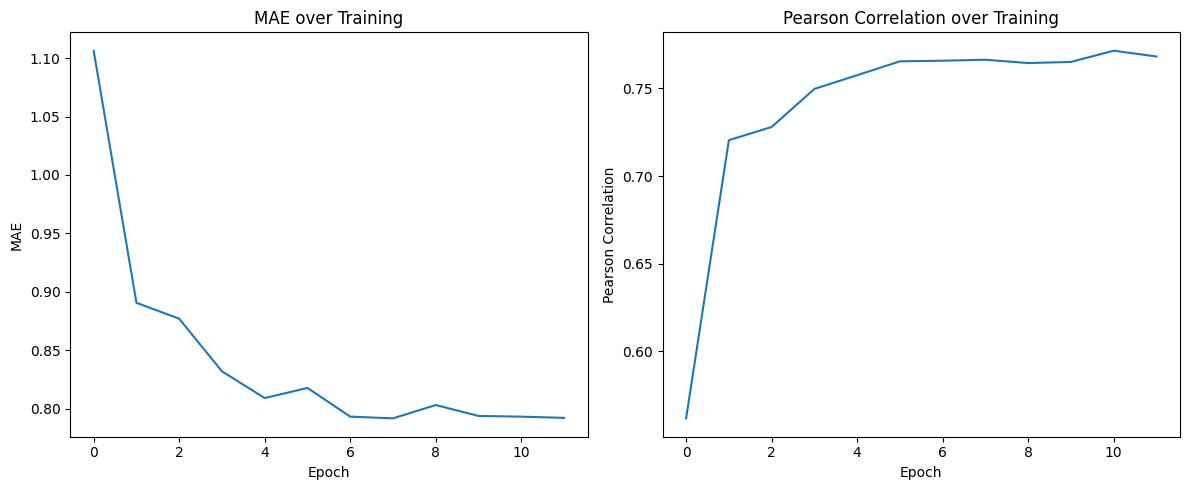

In [ ]:
# Load best model
model.load_state_dict(torch.load(os.path.join(results_dir, "best_model.pt")))

# Test evaluation
test_scores, test_truths, test_loss = evaluate(model, test_loader)
test_metrics = compute_regression_metrics(test_scores, test_truths)
print(f"Test Metrics: MAE: {test_metrics['MAE']:.4f}, Pearson: {test_metrics['Pearson']:.4f}")

# Plot and save loss curves
plot_loss_curves(train_losses, valid_losses, test_loss=test_loss,
                save_path=os.path.join(results_dir, "loss_curves.png"))

# Plot and save regression scatter plot
plot_regression_scatter(test_truths, test_scores, title="Test Regression Predictions",
                      save_path=os.path.join(results_dir, "regression_scatter.png"))

# Plot metrics over epochs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot([m['MAE'] for m in validation_metrics_history])
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('MAE over Training')

plt.subplot(1, 2, 2)
plt.plot([m['Pearson'] for m in validation_metrics_history])
plt.xlabel('Epoch')
plt.ylabel('Pearson Correlation')
plt.title('Pearson Correlation over Training')

plt.tight_layout()
plt.savefig(os.path.join(results_dir, "metrics_over_time.png"))
plt.show()

# Save metrics to file
with open(os.path.join(results_dir, "metrics.txt"), "w") as f:
    f.write("Validation Metrics:\n")
    for k, v in metrics.items():
        f.write(f"{k}: {v:.4f}\n")
    f.write("\nTest Metrics:\n")
    for k, v in test_metrics.items():
        f.write(f"{k}: {v:.4f}\n")